# Research Results — CI/CD Test Charts

Comparing 3 Prompting Strategies: **BP** (Basic Prompting), **CE** (Context Engineering), **SDD** (Specification-Driven Development)

SDD includes two tool variants: VSCode + GitHub Copilot and Cursor

Across 3 Features: **IM** (Inventory Management), **SC** (Shopping Cart), **PD** (Promotions & Discounts)

With 4 Testing Dimensions: **Unit/Integration Tests**, **CodeQL (SAST)**, **DAST (ZAP)**, **SonarQube**

> Based on 12 versions (BP×3 + CE×3 + SDD×6)

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import numpy as np

# ตั้งค่า style
sns.set_theme(style='whitegrid', font_scale=1.1)
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['figure.facecolor'] = 'white'

# สี palette สำหรับ 3 strategies
STRATEGY_COLORS = {
    'BP': '#e74c3c',   # แดง
    'CE': '#3498db',   # น้ำเงิน
    'SDD': '#2ecc71',  # เขียว
}
STRATEGY_NAMES = {
    'BP': 'Basic Prompting',
    'CE': 'Context Engineering',
    'SDD': 'Spec-Driven Dev',
}

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Data Preparation

In [2]:
# === 12 Versions: BP×3, CE×3, SDD×6 (Copilot + Cursor) ===
# Order: IM(BP,CE,SD,CS), SC(BP,CE,SD,CS), PD(BP,CE,SD,CS)
# CS and SD are both SDD

VERSIONS = ['IMBP01','IMCE01','IMSD01','IMCS01',
            'SCBP01','SCCE01','SCSD01','SCCS01',
            'PDBP01','PDCE01','PDSD01','PDCS01']
STRATEGIES = ['BP','CE','SDD','SDD','BP','CE','SDD','SDD','BP','CE','SDD','SDD']
FEATURES   = ['IM','IM','IM','IM','SC','SC','SC','SC','PD','PD','PD','PD']
# Sub-tool label for SDD variants
TOOLS = ['ChatGPT','ChatGPT','Copilot','Cursor',
         'ChatGPT','ChatGPT','Copilot','Cursor',
         'ChatGPT','ChatGPT','Copilot','Cursor']

# === Unit Test Data ===
df_tests = pd.DataFrame({
    'Version':  VERSIONS,
    'Strategy': STRATEGIES,
    'Feature':  FEATURES,
    'Tool':     TOOLS,
    'Passed': [7,7,7,7, 5,5,5,5, 6,6,11,6],
    'Total':  [7,7,7,7, 5,5,5,5, 6,6,11,6],
})
df_tests['Pass_Rate'] = df_tests['Passed'] / df_tests['Total'] * 100

# === CodeQL Data ===
df_codeql = pd.DataFrame({
    'Version':  VERSIONS,
    'Strategy': STRATEGIES,
    'Feature':  FEATURES,
    'Tool':     TOOLS,
    'High':   [5,3,0,0, 0,6,0,0, 0,0,0,0],
    'Medium': [0,1,0,0, 0,0,0,0, 0,1,0,0],
})
df_codeql['Total_Alerts'] = df_codeql['High'] + df_codeql['Medium']

# === DAST Data ===
df_dast = pd.DataFrame({
    'Version':  VERSIONS,
    'Strategy': STRATEGIES,
    'Feature':  FEATURES,
    'Tool':     TOOLS,
    'FAIL': [0,0,0,0, 0,0,0,0, 0,0,0,0],
    'WARN': [7,7,7,8, 7,8,7,8, 8,7,7,7],
    'PASS': [60,60,60,59, 60,59,60,59, 59,60,60,60],
    'Server_Leak': [0,0,0,1, 0,1,0,1, 1,0,0,0],
})

# === SonarQube Data ===
df_sonar = pd.DataFrame({
    'Version':  VERSIONS,
    'Strategy': STRATEGIES,
    'Feature':  FEATURES,
    'Tool':     TOOLS,
    'Security':        [0,0,1,1, 0,0,0,0, 0,0,0,0],
    'Reliability':     [3,19,22,8, 9,9,9,2, 1,16,8,8],
    'Maintainability': [7,26,18,7, 18,12,12,8, 10,20,17,19],
    'Duplications':    [6.90,0.00,3.10,0.00, 5.40,4.30,4.40,0.00, 1.40,0.00,0.00,4.20],
})

print('Data prepared!')
print(f'Versions: {len(VERSIONS)}, Strategies: 3 (BP=3, CE=3, SDD=6)')
print(f'  Unit Tests: {df_tests["Passed"].sum()}/{df_tests["Total"].sum()} passed')
print(f'  CodeQL: {df_codeql["Total_Alerts"].sum()} total alerts')
print(f'  DAST: {df_dast["FAIL"].sum()} fails, {df_dast["WARN"].sum()} warns')
print(f'  SonarQube: Rel={df_sonar["Reliability"].sum()}, Maint={df_sonar["Maintainability"].sum()}')

Data prepared!
Versions: 12, Strategies: 3 (BP=3, CE=3, SDD=6)
  Unit Tests: 77/77 passed
  CodeQL: 16 total alerts
  DAST: 0 fails, 88 warns
  SonarQube: Rel=114, Maint=174


---
## Chart 1: CodeQL Security Alerts by Strategy (Bar Chart)
Key finding ของงานวิจัย — ความแตกต่างด้าน security alerts ระหว่าง strategy

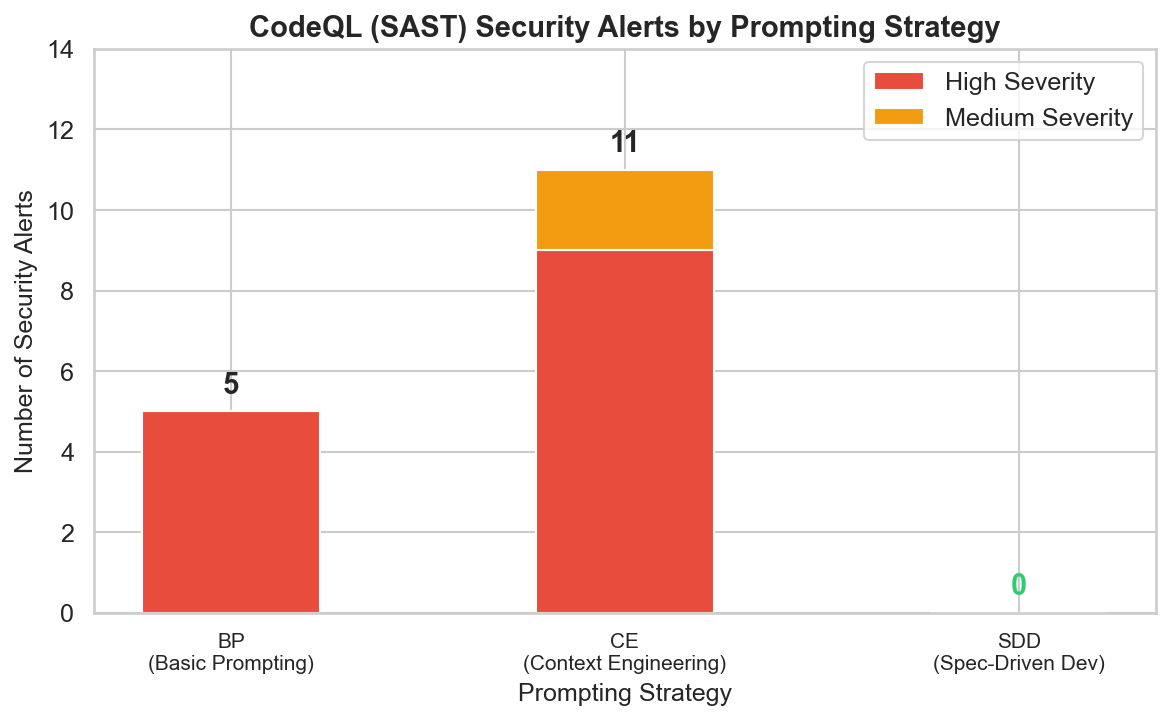

Saved: chart1_codeql_by_strategy.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

strategies = ['BP', 'CE', 'SDD']
high_by_strategy = df_codeql.groupby('Strategy')['High'].sum().reindex(strategies)
med_by_strategy = df_codeql.groupby('Strategy')['Medium'].sum().reindex(strategies)

x = np.arange(len(strategies))
width = 0.45

bars_high = ax.bar(x, high_by_strategy, width, label='High Severity', color='#e74c3c', edgecolor='white')
bars_med = ax.bar(x, med_by_strategy, width, bottom=high_by_strategy, label='Medium Severity', color='#f39c12', edgecolor='white')

for i, (h, m) in enumerate(zip(high_by_strategy, med_by_strategy)):
    total = h + m
    if total > 0:
        ax.text(i, total + 0.3, f'{int(total)}', ha='center', va='bottom', fontweight='bold', fontsize=14)
    else:
        ax.text(i, 0.3, '0', ha='center', va='bottom', fontweight='bold', fontsize=14, color='#2ecc71')

ax.set_xlabel('Prompting Strategy', fontsize=12)
ax.set_ylabel('Number of Security Alerts', fontsize=12)
ax.set_title('CodeQL (SAST) Security Alerts by Prompting Strategy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{s}\n({STRATEGY_NAMES[s]})' for s in strategies], fontsize=10)
ax.legend(loc='upper right')
ax.set_ylim(0, 14)
ax.yaxis.set_major_locator(plt.MultipleLocator(2))

plt.tight_layout()
plt.savefig('chart1_codeql_by_strategy.png', bbox_inches='tight')
plt.show()
print('Saved: chart1_codeql_by_strategy.png')

---
## Chart 2: CodeQL Alerts by Version (Grouped Bar Chart)
แสดงรายละเอียดว่า version ไหนมี alert อะไรบ้าง

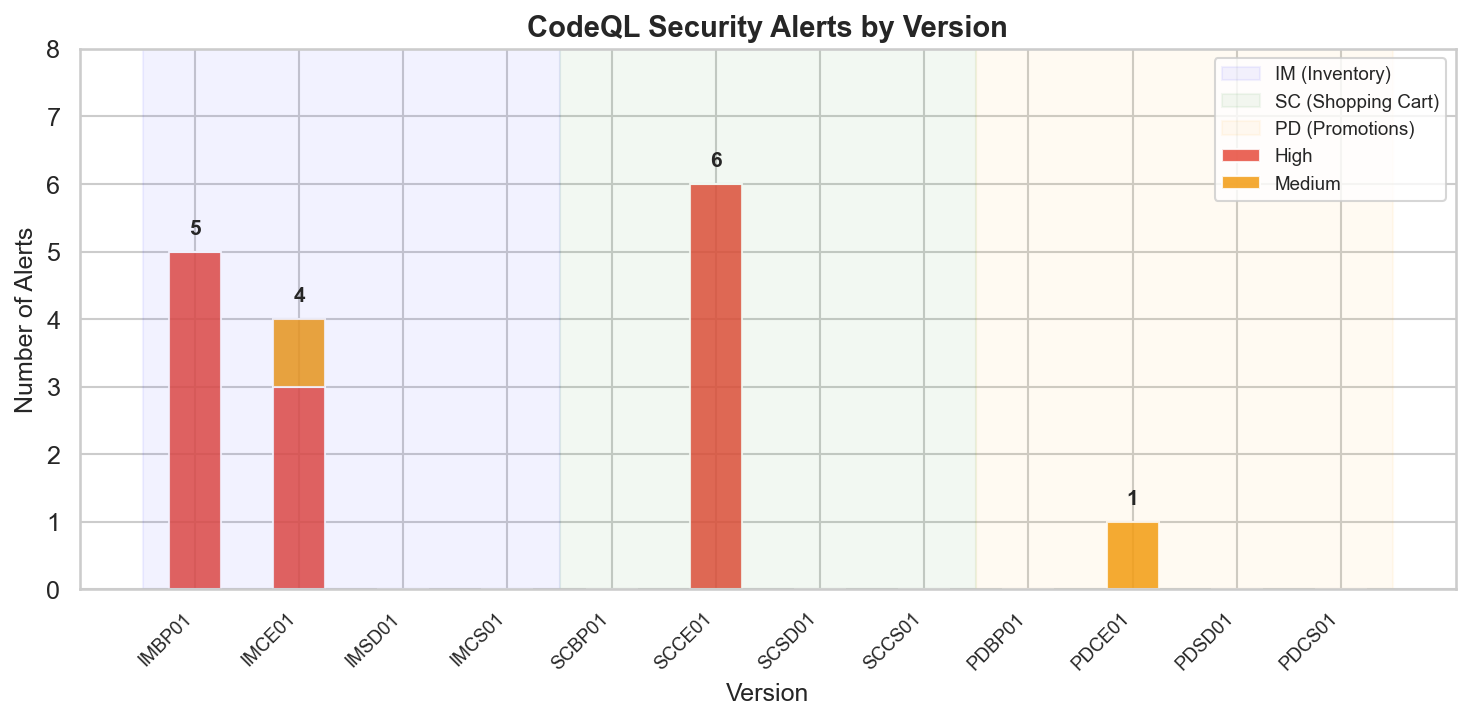

Saved: chart2_codeql_by_version.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

versions = df_codeql['Version'].tolist()
x = np.arange(len(versions))
width = 0.5
colors_bar = [STRATEGY_COLORS[s] for s in df_codeql['Strategy']]

bars = ax.bar(x, df_codeql['High'], width, label='High', color='#e74c3c', alpha=0.85, edgecolor='white')
ax.bar(x, df_codeql['Medium'], width, bottom=df_codeql['High'], label='Medium', color='#f39c12', alpha=0.85, edgecolor='white')

for i, row in df_codeql.iterrows():
    total = row['Total_Alerts']
    if total > 0:
        ax.text(i, total + 0.2, str(int(total)), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Feature background
ax.axvspan(-0.5, 3.5, alpha=0.05, color='blue', label='IM (Inventory)')
ax.axvspan(3.5, 7.5, alpha=0.05, color='green', label='SC (Shopping Cart)')
ax.axvspan(7.5, 11.5, alpha=0.05, color='orange', label='PD (Promotions)')

ax.set_xlabel('Version', fontsize=12)
ax.set_ylabel('Number of Alerts', fontsize=12)
ax.set_title('CodeQL Security Alerts by Version', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(versions, rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 8)

plt.tight_layout()
plt.savefig('chart2_codeql_by_version.png', bbox_inches='tight')
plt.show()
print('Saved: chart2_codeql_by_version.png')

---
## Chart 3: DAST — FAIL / WARN / PASS by Version (Stacked Bar)

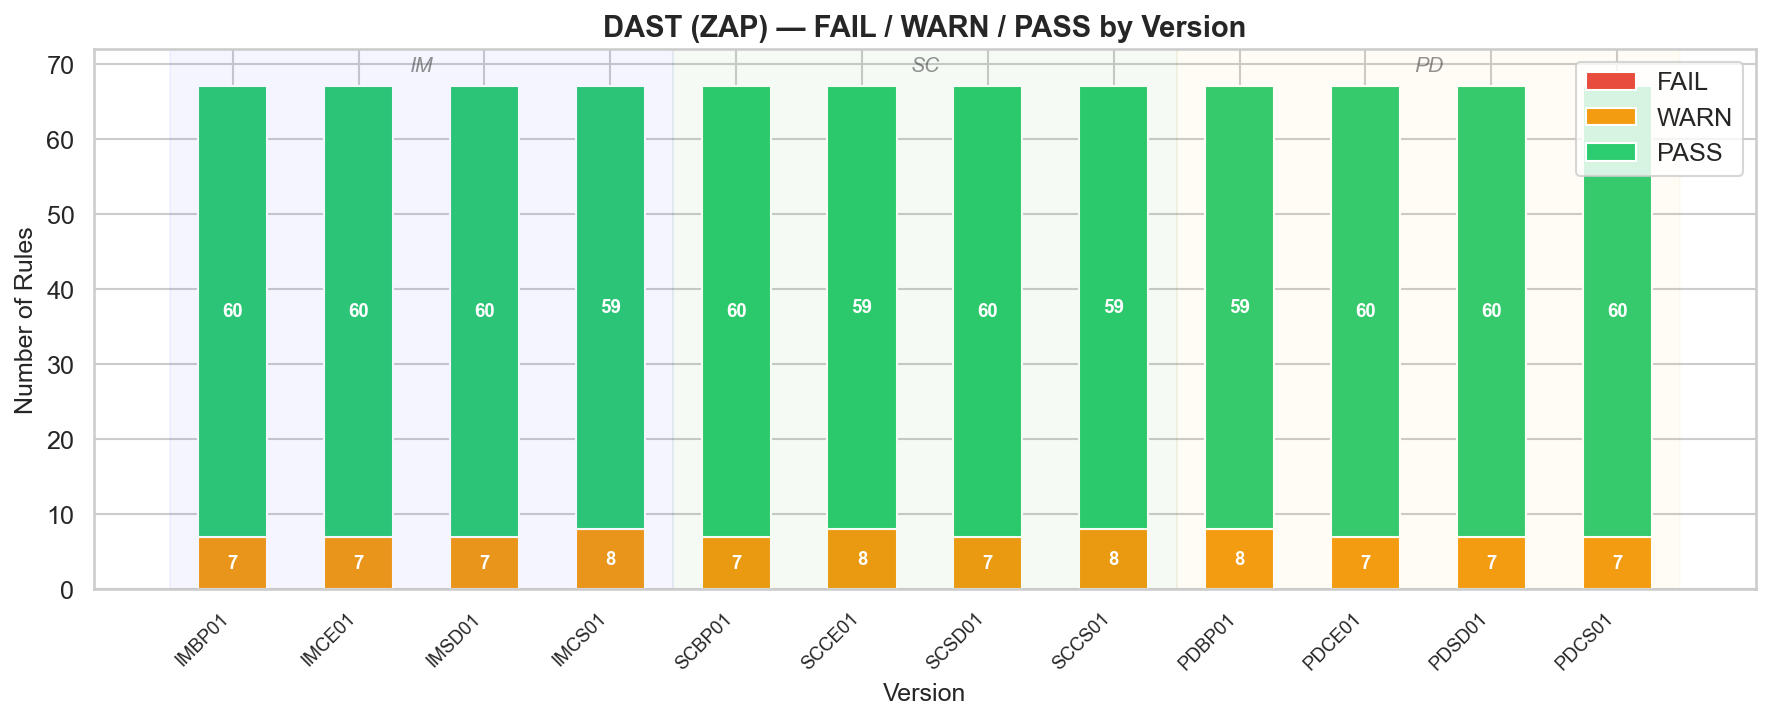

Saved: chart3_dast_by_version.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

versions = df_dast['Version'].tolist()
x = np.arange(len(versions))
width = 0.55

# Stacked: FAIL (bottom), WARN (middle), PASS (top)
ax.bar(x, df_dast['FAIL'], width, label='FAIL', color='#e74c3c', edgecolor='white')
ax.bar(x, df_dast['WARN'], width, bottom=df_dast['FAIL'], label='WARN', color='#f39c12', edgecolor='white')
ax.bar(x, df_dast['PASS'], width, bottom=df_dast['FAIL']+df_dast['WARN'], label='PASS', color='#2ecc71', edgecolor='white')

# Annotate WARN and PASS values
for i, row in df_dast.iterrows():
    # WARN label
    ax.text(i, row['FAIL'] + row['WARN']/2, str(int(row['WARN'])),
            ha='center', va='center', fontweight='bold', fontsize=9, color='white')
    # PASS label
    ax.text(i, row['FAIL'] + row['WARN'] + row['PASS']/2, str(int(row['PASS'])),
            ha='center', va='center', fontweight='bold', fontsize=9, color='white')

# Feature background
ax.axvspan(-0.5, 3.5, alpha=0.04, color='blue')
ax.axvspan(3.5, 7.5, alpha=0.04, color='green')
ax.axvspan(7.5, 11.5, alpha=0.04, color='orange')
ax.text(1.5, 69, 'IM', ha='center', fontsize=10, fontstyle='italic', alpha=0.5)
ax.text(5.5, 69, 'SC', ha='center', fontsize=10, fontstyle='italic', alpha=0.5)
ax.text(9.5, 69, 'PD', ha='center', fontsize=10, fontstyle='italic', alpha=0.5)

ax.set_xlabel('Version', fontsize=12)
ax.set_ylabel('Number of Rules', fontsize=12)
ax.set_title('DAST (ZAP) — FAIL / WARN / PASS by Version', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(versions, rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right')
ax.set_ylim(0, 72)

plt.tight_layout()
plt.savefig('chart3_dast_by_version.png', bbox_inches='tight')
plt.show()
print('Saved: chart3_dast_by_version.png')

---
## Chart 4: DAST — Average WARN / PASS & Server Leak by Strategy

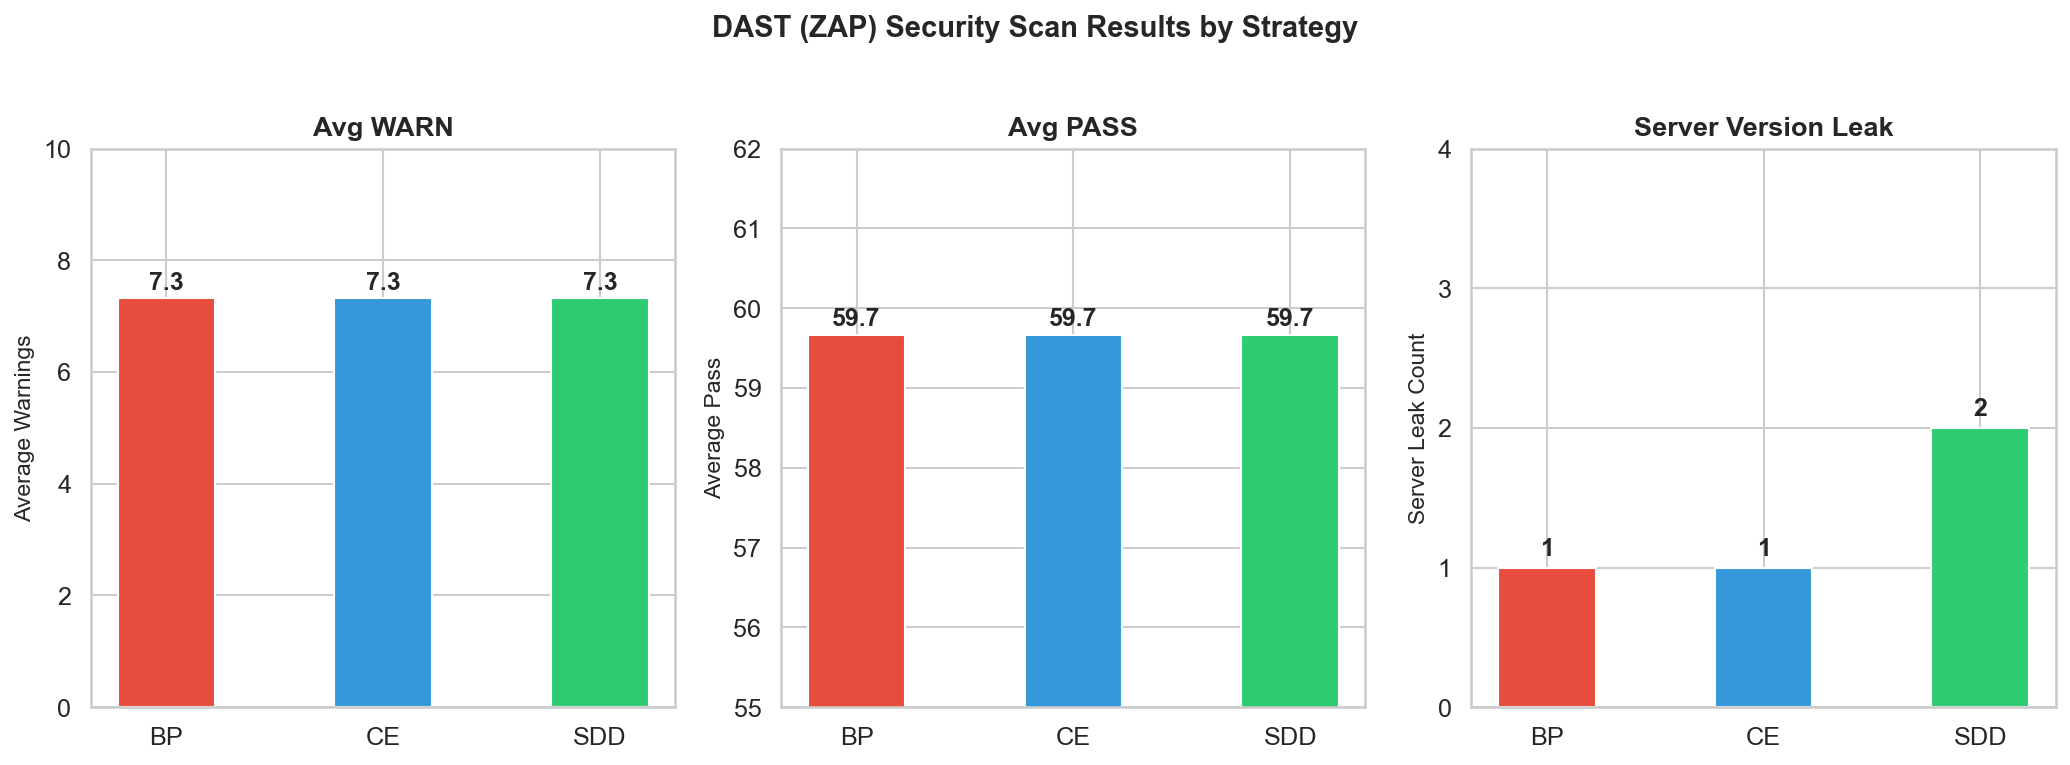

Saved: chart4_dast_by_strategy.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
strategies = ['BP', 'CE', 'SDD']
colors = [STRATEGY_COLORS[s] for s in strategies]

# Left: Average Warnings
ax = axes[0]
avg_warn = df_dast.groupby('Strategy')['WARN'].mean().reindex(strategies)
bars = ax.bar(strategies, avg_warn, color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, avg_warn):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.1f}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Average Warnings', fontsize=11)
ax.set_title('Avg WARN', fontsize=13, fontweight='bold')
ax.set_ylim(0, 10)

# Middle: Average Pass
ax = axes[1]
avg_pass = df_dast.groupby('Strategy')['PASS'].mean().reindex(strategies)
bars = ax.bar(strategies, avg_pass, color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, avg_pass):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.1f}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Average Pass', fontsize=11)
ax.set_title('Avg PASS', fontsize=13, fontweight='bold')
ax.set_ylim(55, 62)

# Right: Server Leak count
ax = axes[2]
leak_count = df_dast.groupby('Strategy')['Server_Leak'].sum().reindex(strategies)
bars = ax.bar(strategies, leak_count, color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, leak_count):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{int(val)}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Server Leak Count', fontsize=11)
ax.set_title('Server Version Leak', fontsize=13, fontweight='bold')
ax.set_ylim(0, 4)
ax.yaxis.set_major_locator(plt.MultipleLocator(1))

plt.suptitle('DAST (ZAP) Security Scan Results by Strategy', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart4_dast_by_strategy.png', bbox_inches='tight')
plt.show()
print('Saved: chart4_dast_by_strategy.png')

---
## Chart 5: DAST Heatmap — Warning Types by Version

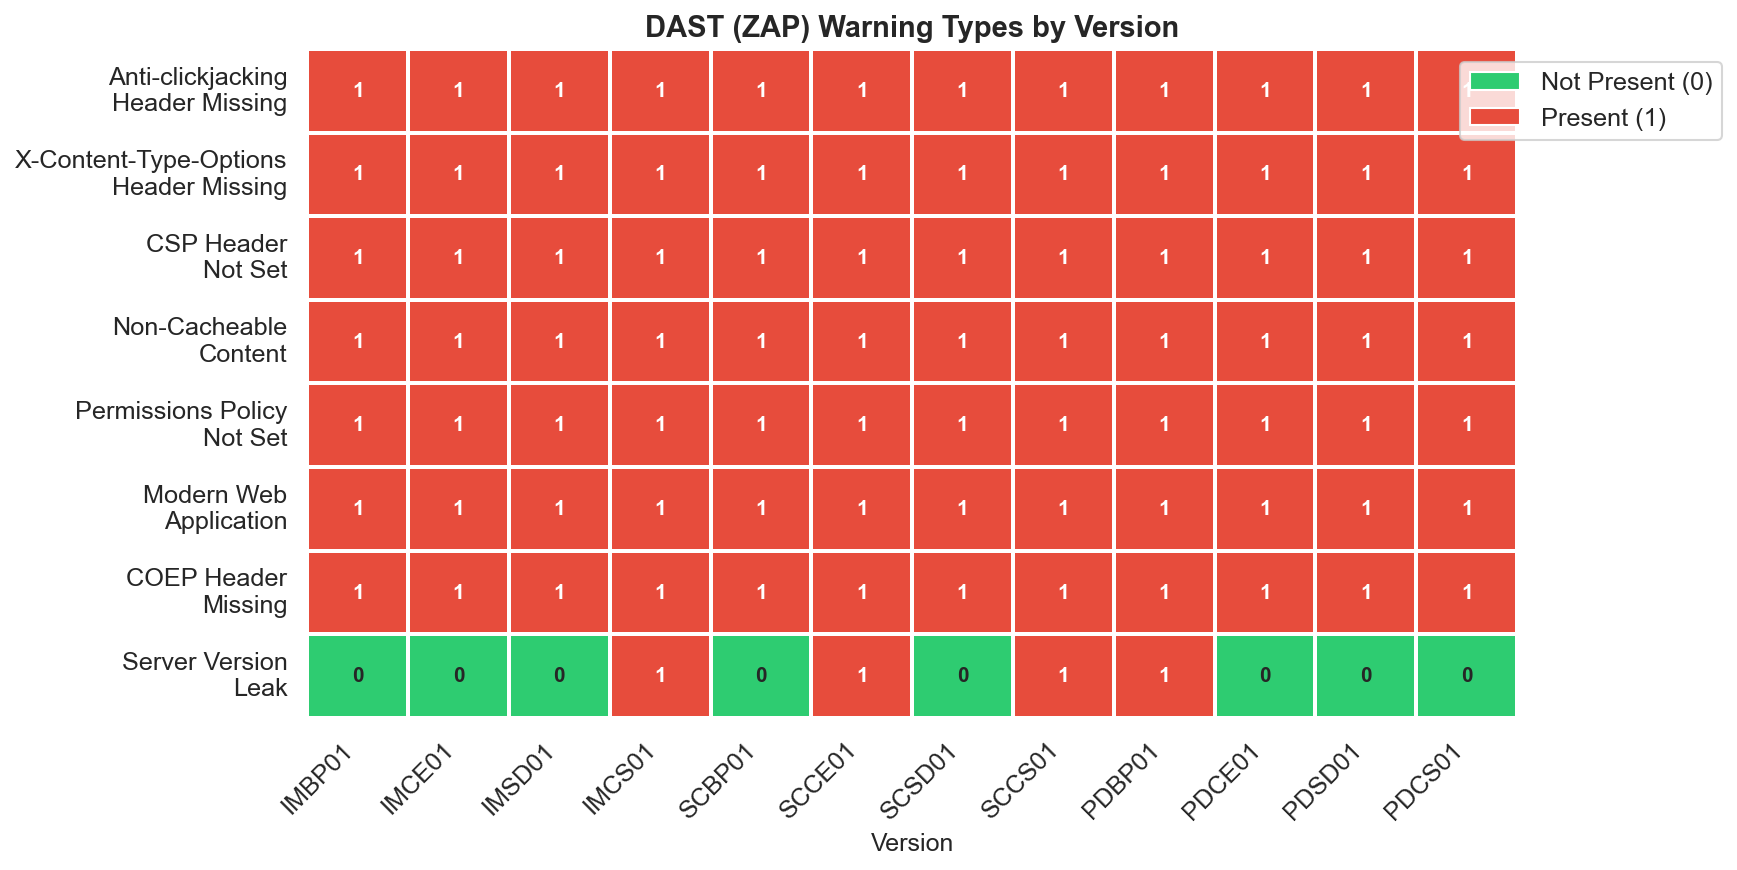

Saved: chart5_dast_heatmap.png


In [7]:
# ZAP Warning types per version (1 = present, 0 = not present)
warnings = [
    'Anti-clickjacking\nHeader Missing',
    'X-Content-Type-Options\nHeader Missing',
    'CSP Header\nNot Set',
    'Non-Cacheable\nContent',
    'Permissions Policy\nNot Set',
    'Modern Web\nApplication',
    'COEP Header\nMissing',
    'Server Version\nLeak',
]

versions = df_dast['Version'].tolist()
heatmap_data = []
for _, row in df_dast.iterrows():
    row_data = [1,1,1,1,1,1,1, row['Server_Leak']]
    heatmap_data.append(row_data)

df_heatmap = pd.DataFrame(heatmap_data, index=versions, columns=warnings)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(df_heatmap.T, annot=True, fmt='d', cmap=['#2ecc71','#e74c3c'],
            linewidths=1, linecolor='white', cbar=False, ax=ax,
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Not Present (0)'),
                   Patch(facecolor='#e74c3c', label='Present (1)')]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.18, 1))

ax.set_title('DAST (ZAP) Warning Types by Version', fontsize=14, fontweight='bold')
ax.set_xlabel('Version', fontsize=12)
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('chart5_dast_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: chart5_dast_heatmap.png')

---
## Chart 6: SonarQube — Reliability & Maintainability Issues by Strategy

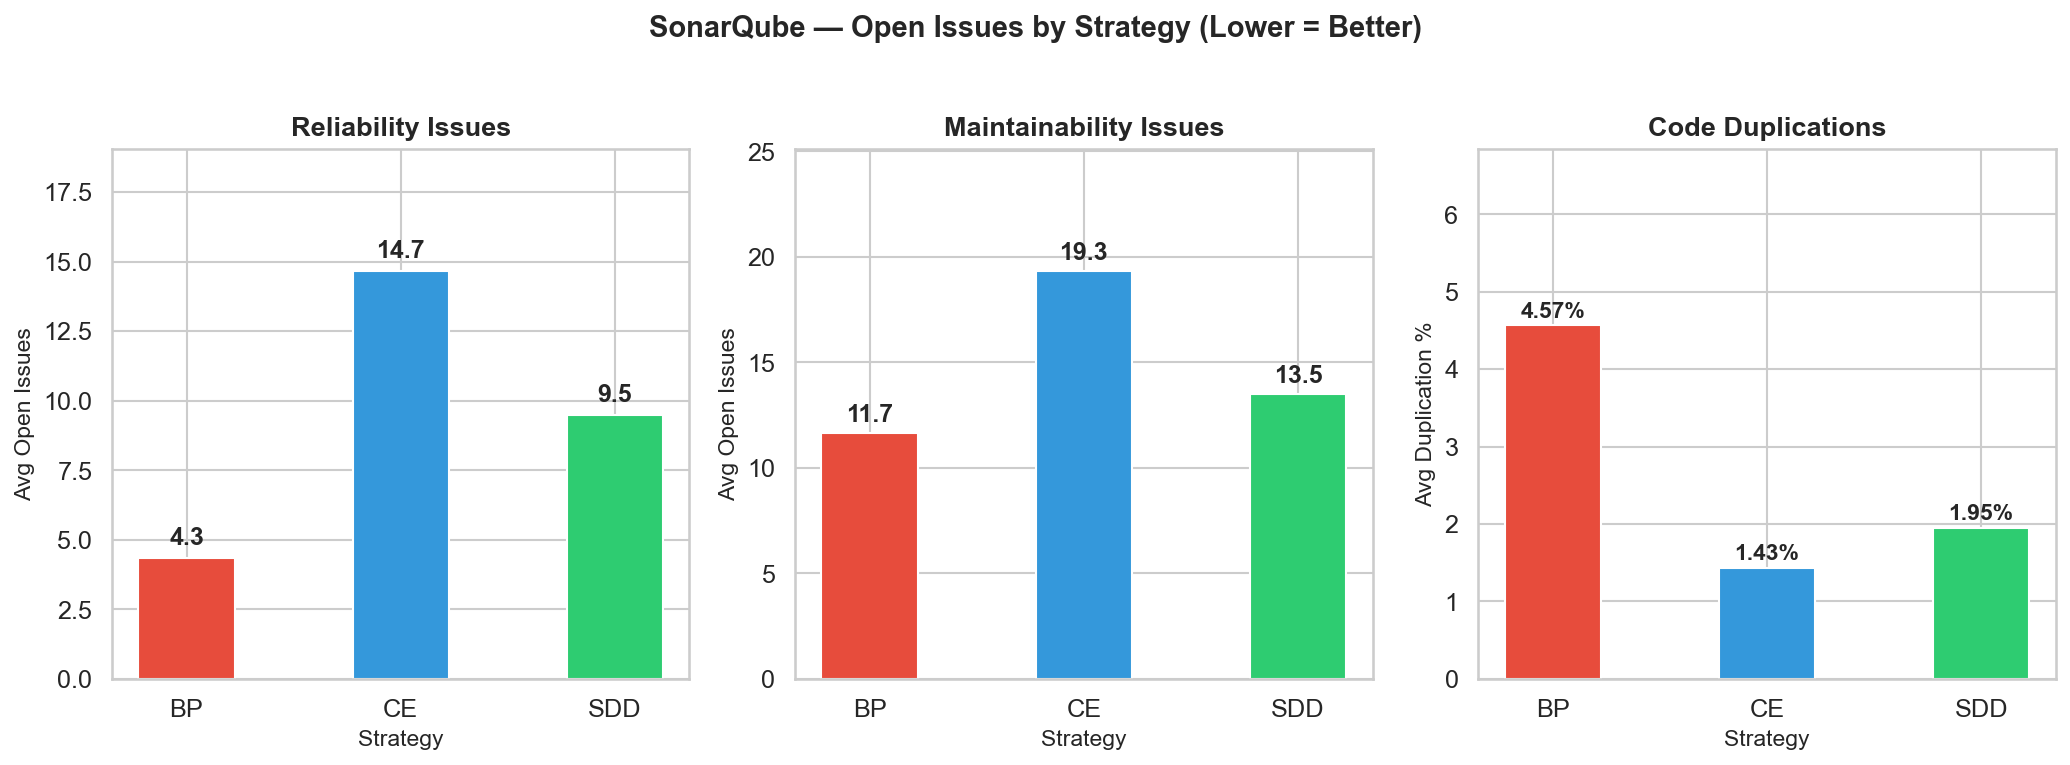

Saved: chart6_sonarqube_by_strategy.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
strategies = ['BP', 'CE', 'SDD']
colors = [STRATEGY_COLORS[s] for s in strategies]

# Left: Reliability
ax = axes[0]
avg_rel = df_sonar.groupby('Strategy')['Reliability'].mean().reindex(strategies)
bars = ax.bar(strategies, avg_rel, color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, avg_rel):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Avg Open Issues', fontsize=11)
ax.set_title('Reliability Issues', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(avg_rel) * 1.3)

# Middle: Maintainability
ax = axes[1]
avg_maint = df_sonar.groupby('Strategy')['Maintainability'].mean().reindex(strategies)
bars = ax.bar(strategies, avg_maint, color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, avg_maint):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Avg Open Issues', fontsize=11)
ax.set_title('Maintainability Issues', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(avg_maint) * 1.3)

# Right: Duplications
ax = axes[2]
avg_dup = df_sonar.groupby('Strategy')['Duplications'].mean().reindex(strategies)
bars = ax.bar(strategies, avg_dup, color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, avg_dup):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('Avg Duplication %', fontsize=11)
ax.set_title('Code Duplications', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(avg_dup) * 1.5)

for a in axes:
    a.set_xlabel('Strategy', fontsize=11)

plt.suptitle('SonarQube — Open Issues by Strategy (Lower = Better)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart6_sonarqube_by_strategy.png', bbox_inches='tight')
plt.show()
print('Saved: chart6_sonarqube_by_strategy.png')

---
## Chart 7: SonarQube — Issues Heatmap by Version

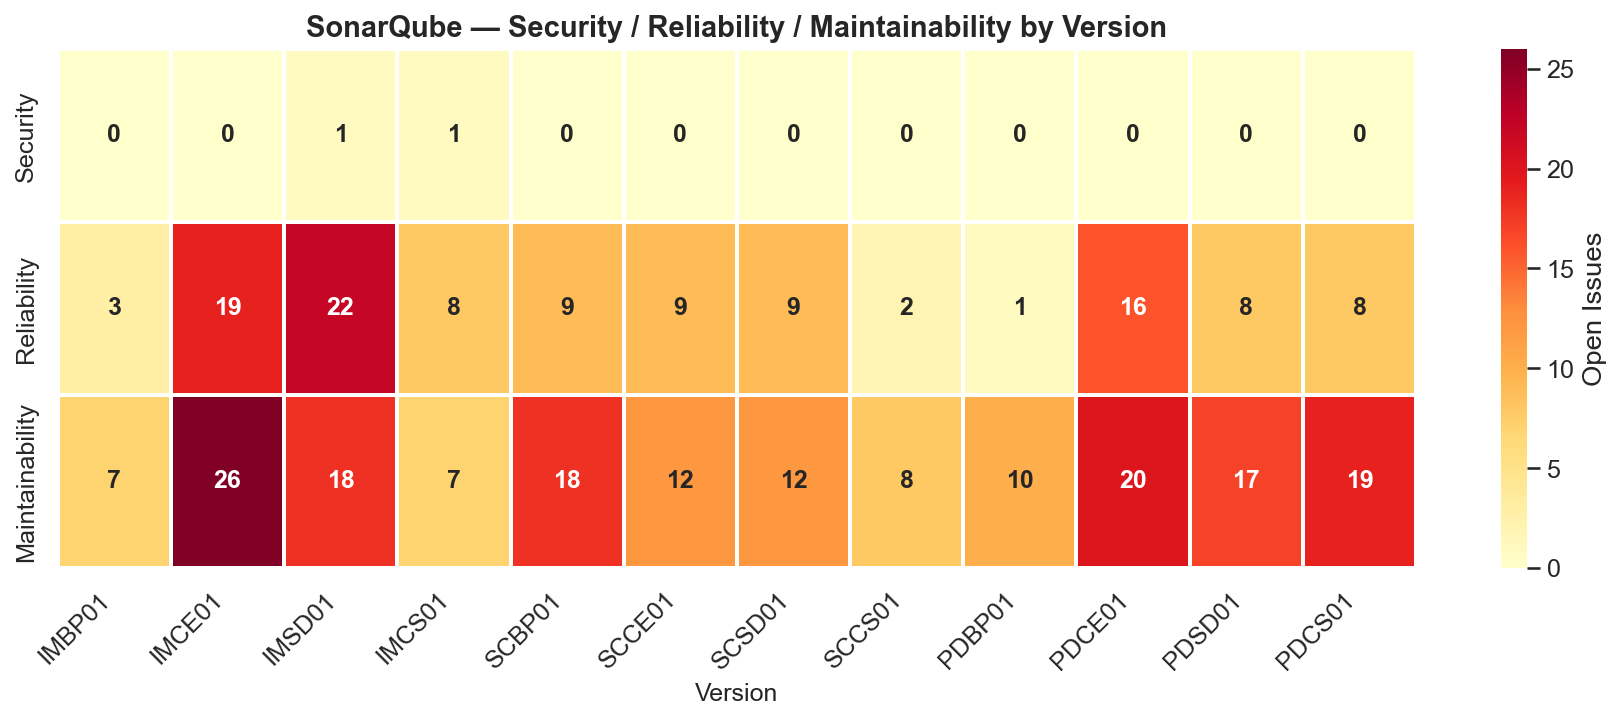

Saved: chart7_sonarqube_heatmap.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

versions = df_sonar['Version'].tolist()
sonar_heatmap = df_sonar[['Security','Reliability','Maintainability']].copy()
sonar_heatmap.index = versions

sns.heatmap(sonar_heatmap.T, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=1, linecolor='white', ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            cbar_kws={'label': 'Open Issues'})

ax.set_title('SonarQube — Security / Reliability / Maintainability by Version', fontsize=14, fontweight='bold')
ax.set_xlabel('Version', fontsize=12)
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('chart7_sonarqube_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: chart7_sonarqube_heatmap.png')

---
## Chart 8: SonarQube — Code Duplications by Version

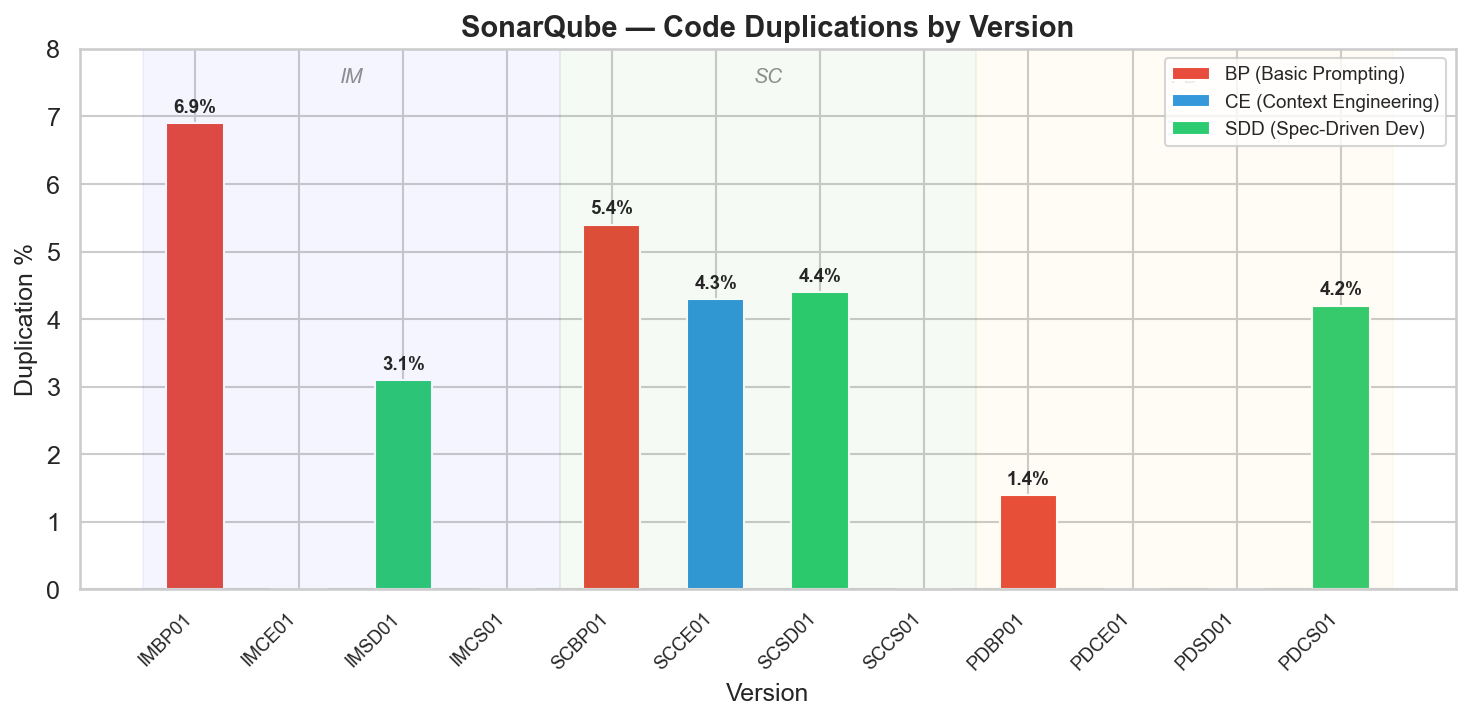

Saved: chart8_sonarqube_duplications.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

versions = df_sonar['Version'].tolist()
x = np.arange(len(versions))
colors_by_strategy = [STRATEGY_COLORS[s] for s in df_sonar['Strategy']]

bars = ax.bar(x, df_sonar['Duplications'], width=0.55, color=colors_by_strategy, edgecolor='white')

for i, (bar, val) in enumerate(zip(bars, df_sonar['Duplications'])):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

# Feature background
ax.axvspan(-0.5, 3.5, alpha=0.04, color='blue')
ax.axvspan(3.5, 7.5, alpha=0.04, color='green')
ax.axvspan(7.5, 11.5, alpha=0.04, color='orange')
ax.text(1.5, 7.5, 'IM', ha='center', fontsize=10, fontstyle='italic', alpha=0.5)
ax.text(5.5, 7.5, 'SC', ha='center', fontsize=10, fontstyle='italic', alpha=0.5)
ax.text(9.5, 7.5, 'PD', ha='center', fontsize=10, fontstyle='italic', alpha=0.5)

ax.set_xlabel('Version', fontsize=12)
ax.set_ylabel('Duplication %', fontsize=12)
ax.set_title('SonarQube — Code Duplications by Version', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(versions, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 8)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=STRATEGY_COLORS[s], label=f'{s} ({STRATEGY_NAMES[s]})')
                   for s in ['BP','CE','SDD']]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('chart8_sonarqube_duplications.png', bbox_inches='tight')
plt.show()
print('Saved: chart8_sonarqube_duplications.png')

---
## Chart 9: Unit Tests — Pass Rate Heatmap by Strategy x Feature

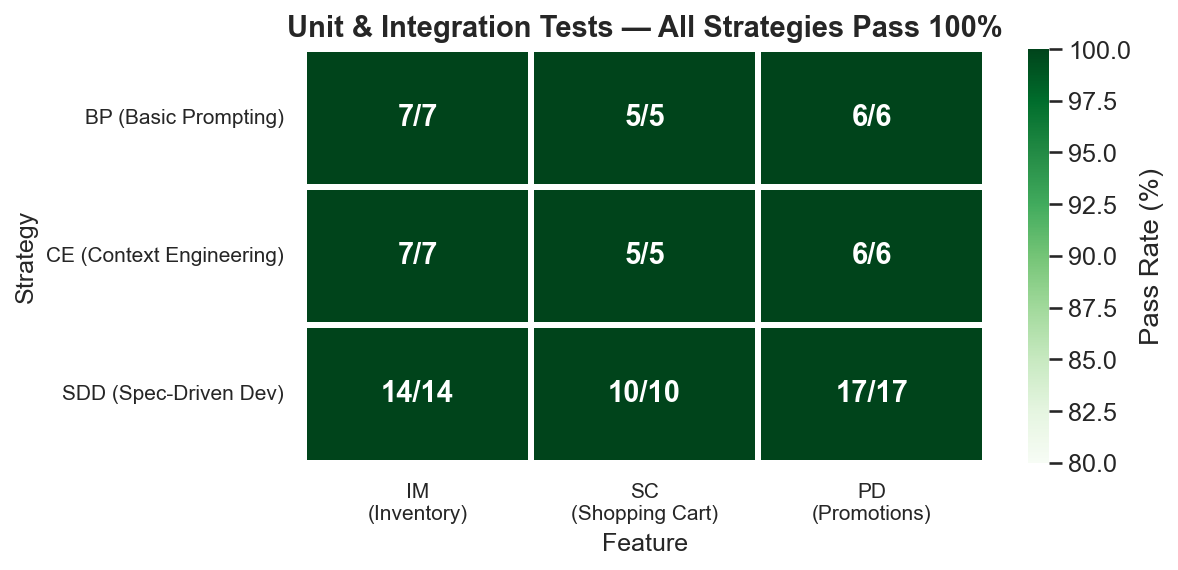

Saved: chart9_unit_tests_heatmap.png


In [11]:
strategies = ['BP', 'CE', 'SDD']
features = ['IM', 'SC', 'PD']

fig, ax = plt.subplots(figsize=(8, 4))

pivot_rate = df_tests.pivot_table(values='Pass_Rate', index='Strategy', columns='Feature').reindex(strategies)[features]
pivot_passed = df_tests.pivot_table(values='Passed', index='Strategy', columns='Feature', aggfunc='sum').reindex(strategies)[features]
pivot_total = df_tests.pivot_table(values='Total', index='Strategy', columns='Feature', aggfunc='sum').reindex(strategies)[features]

annot = pivot_passed.astype(int).astype(str) + '/' + pivot_total.astype(int).astype(str)

sns.heatmap(pivot_rate, annot=annot, fmt='', cmap='Greens', vmin=80, vmax=100,
            linewidths=2, linecolor='white', ax=ax, cbar_kws={'label': 'Pass Rate (%)'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})

ax.set_title('Unit & Integration Tests — All Strategies Pass 100%', fontsize=14, fontweight='bold')
ax.set_ylabel('Strategy', fontsize=12)
ax.set_xlabel('Feature', fontsize=12)
ax.set_yticklabels([f'{s} ({STRATEGY_NAMES[s]})' for s in strategies], rotation=0, fontsize=10)
ax.set_xticklabels(['IM\n(Inventory)', 'SC\n(Shopping Cart)', 'PD\n(Promotions)'], fontsize=10)

plt.tight_layout()
plt.savefig('chart9_unit_tests_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: chart9_unit_tests_heatmap.png')

---
## Chart 10: Radar — Overall Strategy Comparison (All Dimensions)

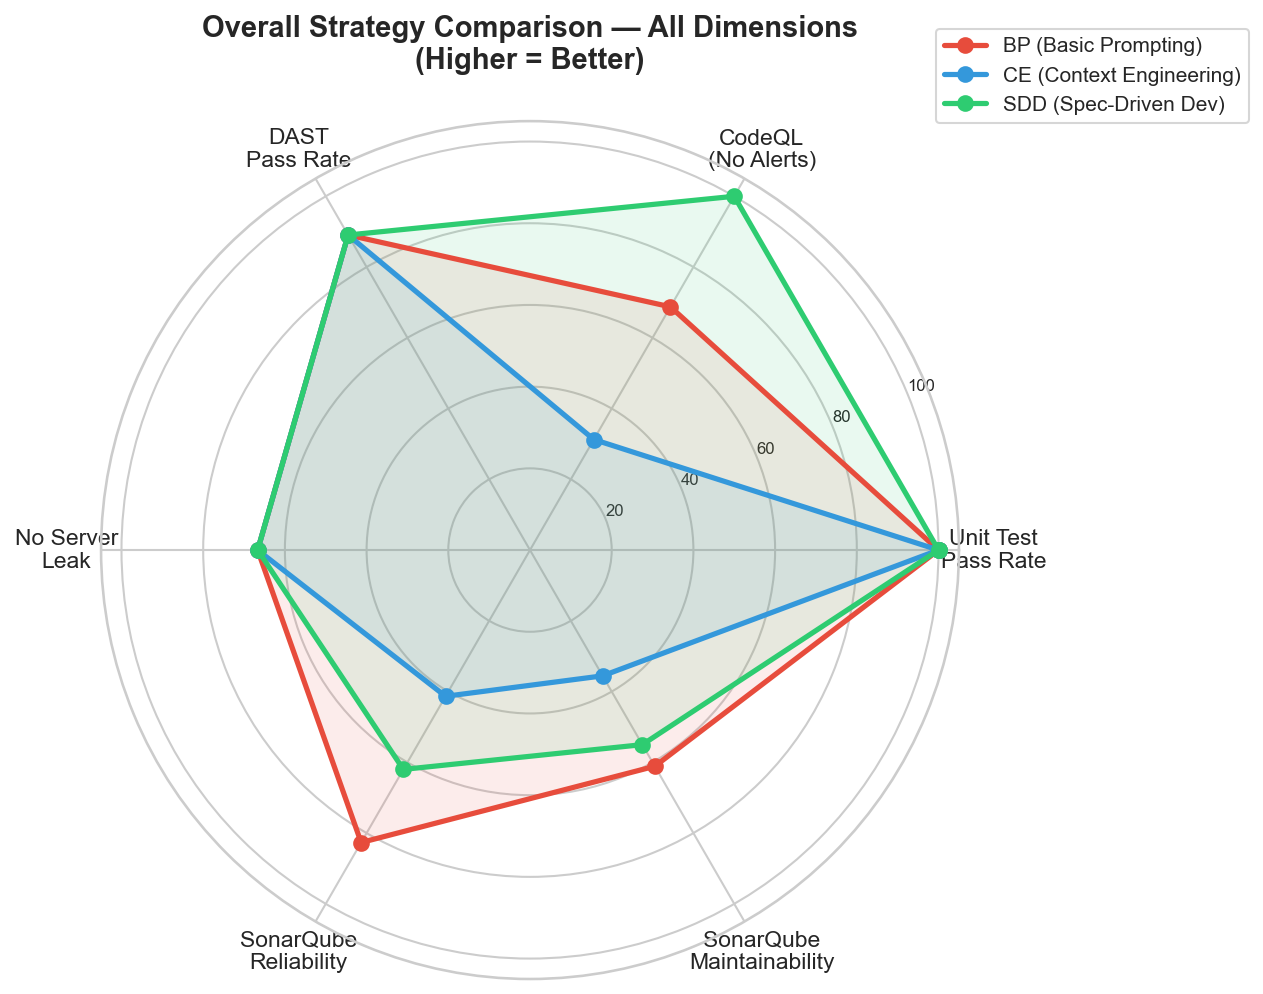

Saved: chart10_radar_comparison.png


In [12]:
strategies = ['BP', 'CE', 'SDD']

radar_data = {}
for s in strategies:
    s_tests = df_tests[df_tests['Strategy'] == s]
    s_codeql = df_codeql[df_codeql['Strategy'] == s]
    s_dast = df_dast[df_dast['Strategy'] == s]
    s_sonar = df_sonar[df_sonar['Strategy'] == s]
    
    # 1. Unit Test Pass Rate
    test_score = s_tests['Pass_Rate'].mean()
    
    # 2. CodeQL (inverse: 0 alerts = 100)
    max_alerts = 16
    codeql_score = max(0, (1 - s_codeql['Total_Alerts'].sum() / max_alerts) * 100)
    
    # 3. DAST Pass Rate
    dast_pass_score = (s_dast['PASS'].mean() / 67) * 100
    
    # 4. No Server Leak (normalize by group size)
    n_versions = len(s_dast)
    leak_score = (1 - s_dast['Server_Leak'].sum() / n_versions) * 100
    
    # 5. SonarQube Reliability (inverse: fewer = better)
    max_rel = 25
    sonar_rel_score = max(0, (1 - s_sonar['Reliability'].mean() / max_rel) * 100)
    
    # 6. SonarQube Maintainability (inverse: fewer = better)
    max_maint = 30
    sonar_maint_score = max(0, (1 - s_sonar['Maintainability'].mean() / max_maint) * 100)
    
    radar_data[s] = [test_score, codeql_score, dast_pass_score, leak_score, sonar_rel_score, sonar_maint_score]

categories = ['Unit Test\nPass Rate', 'CodeQL\n(No Alerts)', 'DAST\nPass Rate',
              'No Server\nLeak', 'SonarQube\nReliability', 'SonarQube\nMaintainability']
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for s in strategies:
    values = radar_data[s] + radar_data[s][:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, label=f'{s} ({STRATEGY_NAMES[s]})',
            color=STRATEGY_COLORS[s], markersize=7)
    ax.fill(angles, values, alpha=0.1, color=STRATEGY_COLORS[s])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 105)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8)
ax.set_title('Overall Strategy Comparison — All Dimensions\n(Higher = Better)', fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.12), fontsize=10)

plt.tight_layout()
plt.savefig('chart10_radar_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: chart10_radar_comparison.png')

---
## Summary

| Chart | File | Description |
|-------|------|-------------|
| 1 | `chart1_codeql_by_strategy.png` | CodeQL Alerts by Strategy |
| 2 | `chart2_codeql_by_version.png` | CodeQL Alerts by Version |
| 3 | `chart3_dast_by_version.png` | DAST FAIL/WARN/PASS by Version |
| 4 | `chart4_dast_by_strategy.png` | DAST Avg WARN/PASS & Server Leak by Strategy |
| 5 | `chart5_dast_heatmap.png` | DAST Warning Types Heatmap |
| 6 | `chart6_sonarqube_by_strategy.png` | SonarQube Issues by Strategy |
| 7 | `chart7_sonarqube_heatmap.png` | SonarQube Issues Heatmap |
| 8 | `chart8_sonarqube_duplications.png` | SonarQube Duplications by Version |
| 9 | `chart9_unit_tests_heatmap.png` | Unit Test Pass Rate Heatmap |
| 10 | `chart10_radar_comparison.png` | Radar — Overall Strategy Comparison |